# 6주차: 실전 딥러닝 1 — solution
---

In [1]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
torch.manual_seed(42); np.random.seed(42)

X_np,y_np=make_moons(n_samples=200,noise=0.3,random_state=42)
X_tr,X_te,y_tr,y_te=train_test_split(X_np,y_np,test_size=0.2,random_state=42)
X_train=torch.tensor(X_tr,dtype=torch.float32); y_train=torch.tensor(y_tr,dtype=torch.float32).unsqueeze(1)
X_test =torch.tensor(X_te,dtype=torch.float32); y_test =torch.tensor(y_te,dtype=torch.float32).unsqueeze(1)


### A-1

In [2]:
model_a1 = nn.Sequential(nn.Linear(2,32), nn.ReLU(), nn.Linear(32,1), nn.Sigmoid())
optimizer_a1 = torch.optim.Adam(model_a1.parameters(), lr=0.01, weight_decay=1e-3)  # ← 정답
print(optimizer_a1)


Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0.001
)


### A-2

In [5]:
model_a2 = nn.Sequential(
    nn.Linear(2,64),  nn.ReLU(),
    nn.Dropout(p=0.3),              # ← 정답
    nn.Linear(64,64), nn.ReLU(),
    nn.Dropout(p=0.3),              # ← 정답
    nn.Linear(64,1),  nn.Sigmoid()
)
print(model_a2)


Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=64, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=64, out_features=1, bias=True)
  (7): Sigmoid()
)


### A-3

In [9]:
torch.manual_seed(0)
model_a3 = nn.Sequential(nn.Linear(2,8), nn.ReLU(), nn.Dropout(p=0.5), nn.Linear(8,1))
x_a3 = torch.ones(1, 2)
model_a3.train()   # ← 정답
out_train = model_a3(x_a3)
model_a3.eval()    # ← 정답
with torch.no_grad():
    out_eval = model_a3(x_a3)
print(f"train(): {out_train.item():.4f}")
print(f"eval():  {out_eval.item():.4f}")
print("Different?", not torch.isclose(out_train, out_eval))


train(): -0.1844
eval():  -0.3699
Different? True


### A-4

In [10]:
z = torch.tensor([-3.0,-1.0,0.0,1.0,3.0], requires_grad=True)
sig = torch.sigmoid(z)
my_grad = sig * (1 - sig)   # ← 정답
sig.sum().backward()
print("My grad:      ", my_grad.detach().round(decimals=4))
print("Autograd grad:", z.grad.round(decimals=4))
print("Match:", torch.allclose(my_grad.detach(), z.grad))
print(f"Max gradient: {my_grad.max().item():.4f}")


My grad:       tensor([0.0452, 0.1966, 0.2500, 0.1966, 0.0452])
Autograd grad: tensor([0.0452, 0.1966, 0.2500, 0.1966, 0.0452])
Match: True
Max gradient: 0.2500


### A-5

In [15]:
torch.manual_seed(0)
layer_a5 = nn.Linear(64, 32)
print("Before:", f"{layer_a5.weight.std().item():.4f}")
nn.init.xavier_uniform_(layer_a5.weight)   # ← 정답
print("After: ", f"{layer_a5.weight.std().item():.4f}")


Before: 0.0727
After:  0.1422


### A-6

In [18]:
torch.manual_seed(0)
layer_a6 = nn.Linear(64, 32)
print("Before:", f"{layer_a6.weight.std().item():.4f}")
nn.init.kaiming_normal_(layer_a6.weight)   # ← 정답
print("After: ", f"{layer_a6.weight.std().item():.4f}")


Before: 0.0727
After:  0.1710


### A-7

In [19]:
torch.manual_seed(42)
model_a7 = nn.Sequential(nn.Linear(2,16), nn.ReLU(), nn.Linear(16,1), nn.Sigmoid())
lambda_ = 1e-3; crit_a7 = nn.BCELoss()
pred = model_a7(X_train); bce = crit_a7(pred, y_train)

# L2 penalty: bias 제외하고 weight만 합산하는 것이 일반적
l2_penalty = sum(p.pow(2).sum() for name, p in model_a7.named_parameters() if 'weight' in name)  # ← 정답

loss_reg = bce + lambda_ * l2_penalty
print(f"BCE: {bce.item():.6f}, L2: {l2_penalty.item():.6f}, Total: {loss_reg.item():.6f}")


BCE: 0.644012, L2: 5.970440, Total: 0.649982


### A-8

In [20]:
torch.manual_seed(42)
model_a8 = nn.Sequential(
    nn.Linear(2,32), nn.Sigmoid(), nn.Linear(32,32), nn.Sigmoid(),
    nn.Linear(32,32), nn.Sigmoid(), nn.Linear(32,1),  nn.Sigmoid()
)
loss_a8 = nn.BCELoss()(model_a8(X_train), y_train)
loss_a8.backward()
linear_layers = [m for m in model_a8 if isinstance(m, nn.Linear)]
print("Gradient norms (output → input):")
for i, layer in enumerate(reversed(linear_layers)):
    grad_norm = layer.weight.grad.norm().item()   # ← 정답
    print(f"  Layer {len(linear_layers)-i}: {grad_norm:.6f}")


Gradient norms (output → input):
  Layer 4: 0.155790
  Layer 3: 0.019028
  Layer 2: 0.004923
  Layer 1: 0.000794


### B-1

In [28]:
def make_model_with_dropout(dropout_p=0.0):
    layers = [nn.Linear(2,64), nn.ReLU()]
    if dropout_p > 0: layers.append(nn.Dropout(dropout_p))
    layers += [nn.Linear(64,64), nn.ReLU()]
    if dropout_p > 0: layers.append(nn.Dropout(dropout_p))
    layers += [nn.Linear(64,1), nn.Sigmoid()]
    return nn.Sequential(*layers)

def run_experiment(dropout_p, weight_decay, epochs=2000):
    torch.manual_seed(42)
    model = make_model_with_dropout(dropout_p)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=weight_decay)  # ← 정답
    crit  = nn.BCELoss()                                                               # ← 정답
    for _ in range(epochs):
        model.train()                                                                  # ← 정답
        opt.zero_grad(); l=crit(model(X_train),y_train); l.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        final_train = crit(model(X_train), y_train).item()                            # ← 정답
        final_test  = crit(model(X_test),  y_test).item()                             # ← 정답
        acc = ((model(X_test)>0.5).float()==y_test).float().mean().item()             # ← 정답
    return final_train, final_test, acc

conditions = {
    "Baseline":     dict(dropout_p=0.0, weight_decay=0.0),
    "L2 only":      dict(dropout_p=0.0, weight_decay=1e-3),
    "Dropout only": dict(dropout_p=0.3, weight_decay=0.0),
    "L2 + Dropout": dict(dropout_p=0.3, weight_decay=1e-3),
}
print(f"{'Condition':20s} {'Train Loss':>12s} {'Test Loss':>10s} {'Test Acc':>10s}")
print("-"*58)
for name, kwargs in conditions.items():
    tr_l,te_l,acc = run_experiment(**kwargs)
    print(f"{name:20s} {tr_l:>12.4f} {te_l:>10.4f} {acc*100:>9.1f}%")


Condition              Train Loss  Test Loss   Test Acc
----------------------------------------------------------
Baseline                   0.0005     3.9898      87.5%
L2 only                    0.0711     0.7894      90.0%
Dropout only               0.0452     5.4495      87.5%
L2 + Dropout               0.1129     0.6437      90.0%


### B-2 (숙제)

Zero init      : final=0.6928, grad norm=0.000000
Small random   : final=0.1468, grad norm=0.065453
He init        : final=0.0147, grad norm=0.089343


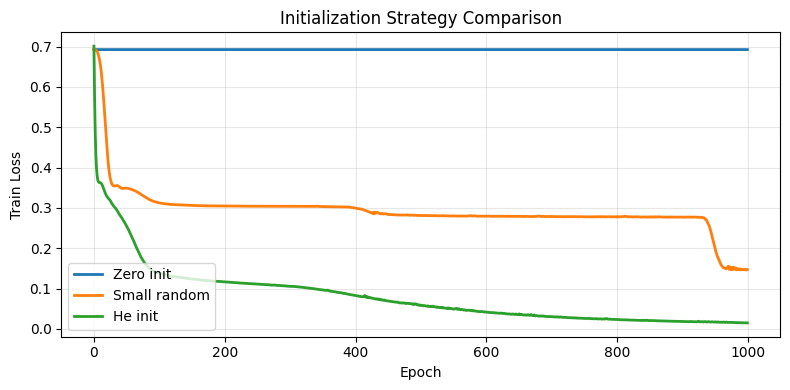

In [22]:
def apply_init(model, init_fn):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            init_fn(m.weight); nn.init.zeros_(m.bias)

def train_with_init(init_fn, label, epochs=1000):
    torch.manual_seed(42)
    model = nn.Sequential(nn.Linear(2,32), nn.ReLU(), nn.Linear(32,32), nn.ReLU(), nn.Linear(32,1), nn.Sigmoid())
    apply_init(model, init_fn)                                    # ← 정답
    opt  = torch.optim.Adam(model.parameters(), lr=0.01)         # ← 정답
    crit = nn.BCELoss()                                           # ← 정답
    losses = []
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        l=crit(model(X_train),y_train); l.backward(); opt.step()
        losses.append(l.item())                                   # ← 정답
    first_linear = [m for m in model.modules() if isinstance(m, nn.Linear)][0]
    grad_norm = first_linear.weight.grad.norm().item() if first_linear.weight.grad is not None else 0.0
    return losses, grad_norm

init_strategies = {
    "Zero init":    lambda w: nn.init.zeros_(w),
    "Small random": lambda w: nn.init.normal_(w, 0, 0.01),
    "He init":      lambda w: nn.init.kaiming_normal_(w),
}
fig, ax = plt.subplots(figsize=(8,4))
for label, init_fn in init_strategies.items():
    losses, grad_norm = train_with_init(init_fn, label)
    ax.plot(losses, label=label, lw=2)                            # ← 정답
    print(f"{label:15s}: final={losses[-1]:.4f}, grad norm={grad_norm:.6f}")
ax.set_xlabel("Epoch"); ax.set_ylabel("Train Loss")
ax.set_title("Initialization Strategy Comparison")
ax.legend(); ax.grid(True,alpha=0.3); plt.tight_layout(); plt.show()
